# Estimating cosmological parameters and selecting cosmological models with SNIa data

We find best-fit parameters and select the best cosmological model using the [Supernova Cosmology Project](http://supernova.lbl.gov/union/) data. These consist of measurements of the distance modulus of 580 Supernovae Ia, an excellent standard candle:

$$DM = m_B-M_B$$

with $m_B$ apparent magnitude and $M_B$ absolute magnitude in some band (e.g. the blue band, $B$). The absolute magnitude is inferred from the shape of $m_B(t)$. This can be related in turn to the redshift $z$ of the source:

$$DM(z, \boldsymbol{\theta})=5 \log_{10} \dfrac{d_{L}(z, \boldsymbol{\theta})}{\text{Mpc}}+25$$

with $d_L$ luminosity distance of the source. In the *flat* Standard Cosmological model LCDM, this is given by

$$d_{L}\left(z; h_0, \Omega_{m}\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h_0}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})}}$$

with $h_0$ is the dimensionless Hubble constant and $\Omega_{m}$ the density parameter of matter. In this model Dark Energy (DE) is interpreted as a constant term ($\Lambda$) in Einstein's field equations of General Relativity.
A simple generalization of this model is to consider DE as a perfect fluid with equation of state $p=w_0\rho$, with $w_0$ the equation of state parameter (wCDM). It reduces to LCDM for $w_0 = -1$ = const. In this model the luminosity distance is

$$d_{L}\left(z; h_0, \Omega_{m}, w_0\right)=\dfrac{c}{100\dfrac{\text{s*Mpc}}{\text{Km}} h_0}(1+z)
\int_{0}^{z} \frac{\mathrm{d} z^{\prime}}{\sqrt{\Omega_{m}\left(1+z^{\prime}\right)^{3}+(1-\Omega_{m})\left(1+z^{\prime}\right)^{3(1+w_0)}}}$$

To sum up, we will explore two possibilities

1.  flat LCDM model: $w_0=-1=\rm{const}$,  $\quad\boldsymbol{\theta}=(h_0, \Omega_{m})$
2.  flat wCDM model: variable $w_0$, $\quad \boldsymbol{\theta}=(h_0, \Omega_{m}, w_0)$


In [155]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
from scipy.integrate import quad, nquad
import corner
from astropy.cosmology import LambdaCDM
from astropy.cosmology import wCDM
from astropy import units as aq
from scipy import stats
import time
import scipy.optimize

params = {
    'lines.linewidth': 2,
    'font.size': 17,
    'axes.labelsize': 'large',
    'axes.titlesize': 'large',
    'xtick.labelsize': 'large',
    'ytick.labelsize': 'large',
}
plt.rcParams.update(params)

### Imports

In [156]:
root = '/Users/davidesciotti/Documents/Work/Code/Astrostats'
data_union = np.genfromtxt(f'{root}/input/SCPUnion2.1_mu_vs_z.txt')

z_obs = data_union[:, 1]
y_obs = data_union[:, 2]
sigma_y = data_union[:, 3]
N_obs = z_obs.size

models = ['LCDM', 'wCDM']
c = 299792.458  # km/s

### Settings

In [157]:
prior_type = 'flat'
model = 'LCDM'

par_names_dict = {'LCDM': ['h', 'Om'], 'wCDM': ['h', 'Om', 'w0']}
par_names_tex_dict = {
    'LCDM': [r'$h$', r'$\Omega_m$'],
    'wCDM': [r'$h$', r'$\Omega_m$', r'$w_0$'],
}
par_names = par_names_dict[model]
par_names_tex = par_names_tex_dict[model]

dof_dict = {
    'LCDM': N_obs - len(par_names_dict['LCDM']),
    'wCDM': N_obs - len(par_names_dict['wCDM']),
}


prior_ranges = {
    'h': (0.50, 0.90),
    'Om': (0.0, 1.0),
    'w0': (-2.0, 0.0),
}

# guess starting point to search minimum with scipy.optimize.minimize
theta_fid = {'h': 0.70, 'Om': 0.28, 'w0': -1.0}

p_val_threshold = 0.05

# emcee
Nsteps = 2000
Nwalkers = 10
burn_in_fraction = 0.2  # fraction of initial steps to discard as burn-in

# nautilus
n_live = 2000
seed = 42

### Plot data: $(z_i, DM_i)$

*   No uncertainties on $x$ axis
*   Uncorrelated measurements (diagonal covariance matrix in $y$)

/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_1538/3399390049.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={'size': 16})


Text(0, 0.5, '$\\mu(z)$')

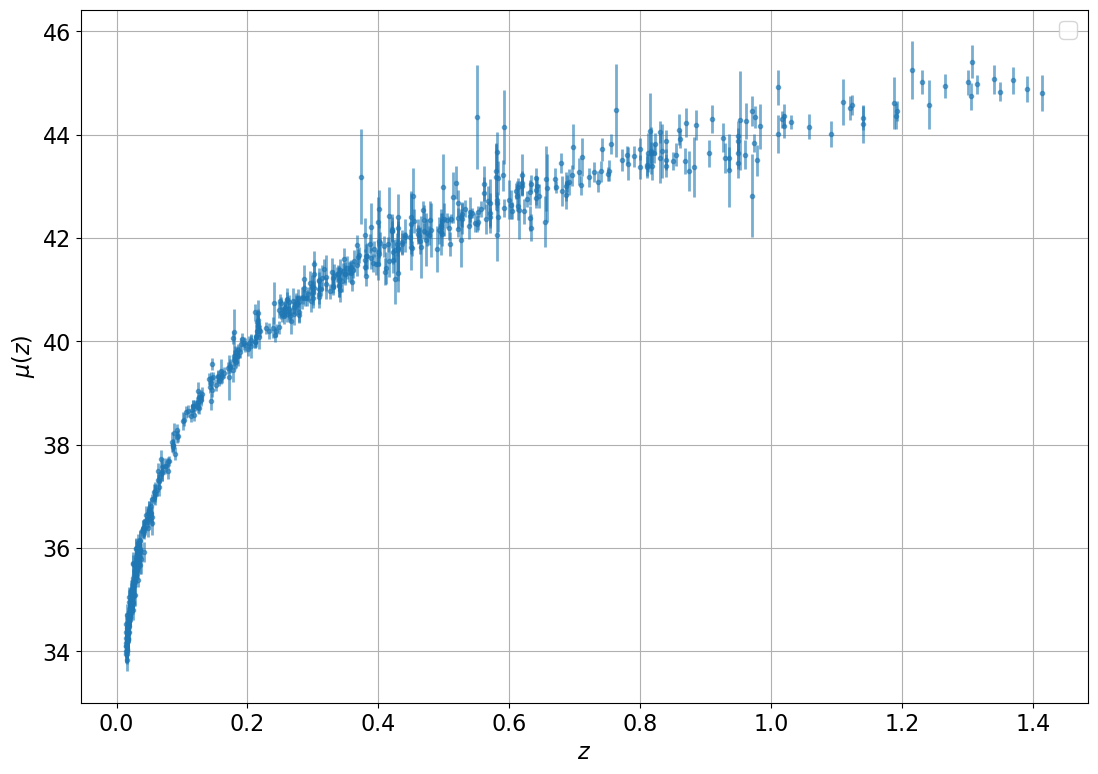

In [158]:
plt.figure(figsize=(13, 9))
plt.tick_params(labelsize=16)
plt.errorbar(z_obs, y_obs, yerr=sigma_y, fmt='.', alpha=0.6)
plt.grid()
plt.legend(prop={'size': 16})
plt.xlabel(r'$z$', fontsize=16)
plt.ylabel(r'$\mu(z)$', fontsize=16)

# Maximum Likelihood Estimation
As a starting point, let's try to estimate the best-fit parameters by maximizing the logarithm of the likelihood LL (the log is a monothonic function, so it doesn't affect the location of the maximum) - or equivalently by minimizing the negative log likelihood, NLL. \
As seen, this has a couple issues:
- it is just a point estimate, and does not take into account the full shape of $\mathcal{L}(\boldsymbol{\theta};\text{data})$
- it does not take into account the prior probabilities $p(\boldsymbol{\theta})$, considering de facto $p(\boldsymbol{\theta}|\text{data})=p(\text{data}|\boldsymbol{\theta})$

We work with a Gaussian Likelihood, describing our error model (we assume the data points to be normally distributed around their predicted values):

$$p(\text{data}|\boldsymbol\theta) = {\cal L}(\boldsymbol\theta ; \text{data}) = \prod_{i=1}^N \dfrac{1}{\sqrt{2\pi}\sigma_i}\exp\left[ -\dfrac{1}{2}\left( \dfrac{y_i-DM (z_i, \boldsymbol{\theta})}{\sigma_i}\right)^2 \right]$$

where $\text{data}=(\boldsymbol{z}, \boldsymbol{y}, \boldsymbol{\sigma})$. The total likelihood is the product of the individual likelihoods $\cal{L}_i$, because we are assuming uncorrelated measurements both on the $x$ and the $y$ axis. $N$ indicates the number of data points (= 580).

We note that, since we're working with diagonal covariance and Gaussian likelihood, maximizing the LL is the same as finding the "least squares fit", i.e. minimizing the quantity

$$\chi^{2}=\sum_{i=1}^{N} \left( \frac{y_{i}-DM\left(z_{i}, \boldsymbol{\theta}\right)}{\sigma_{i}} \right)^{2}.$$



### Define model, priors, likelihood and posterior

In [159]:
def model_prediction(z, theta, which_model):
    if which_model == 'LCDM':
        h, Om = theta
        Ode = 1 - Om
        dl = LambdaCDM(H0=100.0 * h, Om0=Om, Ode0=Ode).luminosity_distance(z)
    elif which_model == 'wCDM':
        h, Om, w0 = theta
        Ode = 1 - Om
        dl = wCDM(H0=100.0 * h, Om0=Om, Ode0=Ode, w0=w0).luminosity_distance(z)
    dm = 5.0 * np.log10(dl.to(aq.Mpc) / (1.0e-5 * aq.Mpc))
    return dm


def ln_prior(theta):
    if model == 'LCDM':
        h, Om = theta
    elif model == 'wCDM':
        h, Om, w0 = theta

    ln_prior_val = 0.0

    ####################### FLAT PRIORS ######################
    if prior_type == 'flat':
        for param, param_name in zip(theta, par_names):
            # if outside the prior range, prior is 0 (and log is -inf)
            if (
                param < prior_ranges[param_name][0]
                or param > prior_ranges[param_name][1]
            ):
                return -np.inf
            # otherwise it's 1/delta, where delta is the width of the prior range
            else:
                delta = prior_ranges[param_name][1] - prior_ranges[param_name][0]
                ln_prior_val += np.log(1 / delta)

    # TODO remove this?
    ####################### GAUSSIAN PRIORS ######################
    # from eBoss 2020: https://www.sdss.org/science/cosmology-results-from-eboss/
    elif prior_type == 'gauss':
        mu = exp_values_L[0]
        sigma = 0.003  # h
        ln_prior_val += (
            np.log(1.0 / (np.sqrt(2 * np.pi) * sigma)) - 0.5 * (h - mu) ** 2 / sigma**2
        )

        mu = exp_values_L[1]
        sigma = 0.004  # Om
        if Om <= 0:
            return -np.inf
        else:
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (Om - mu) ** 2 / sigma**2
            )

        if model == 'wCDM':
            mu = exp_values_w[0]
            sigma = 0.007  # h
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (h - mu) ** 2 / sigma**2
            )

            mu = exp_values_w[1]
            sigma = 0.006  # Om
            if Om <= 0:
                return -np.inf
            else:
                ln_prior_val += (
                    np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                    - 0.5 * (Om - mu) ** 2 / sigma**2
                )

            mu = exp_values_w[2]
            sigma = 0.02  # Om
            ln_prior_val += (
                np.log(1.0 / (np.sqrt(2 * np.pi) * sigma))
                - 0.5 * (w0 - mu) ** 2 / sigma**2
            )
    ### end of gaussian priors definition
    return ln_prior_val


def ln_likelihood(theta, data, which_model):

    z_obs, y_obs, sigma_y = data

    # note that this will break for a non-diagonal covmat!
    chi2 = (
        (y_obs - model_prediction(z_obs, theta, which_model)) / sigma_y
    ) ** 2 + 2 * np.log(sigma_y)

    # in principle, the first term could be dropped, as it doesn't depend on theta
    return -0.5 * N_obs * np.log(2 * np.pi) - 0.5 * np.sum(chi2)


def ln_posterior(theta, data, which_model):
    # if outside the prior range, don't bother computing the likelihood,
    # just return -inf for the log posterior
    if np.isinf(ln_prior(theta)):
        return -np.inf
    else:
        return ln_likelihood(theta, data, which_model) + ln_prior(theta)


# these are all quite ugly, use simpson or trapz instead of sum?
def expectation(x, fx):
    return np.sum(x * fx) / np.sum(fx)


def variance(x, fx):
    mean = expectation(x, fx)
    return np.sum((x - mean) ** 2 * fx) / np.sum(fx)


def get_prob(fx, low, high):
    low_index = np.digitize(low, bins)
    high_index = np.digitize(high, bins)
    return np.sum(fx[low_index:high_index]) / np.sum(fx)


### Find $\theta_{MLE}$ by minimizing the NLL
Use minimization routine $\tt {scipy.optimize.minimize}$ to find the minimum of the NLL

In [160]:
theta_mle_dict = {}
for i, model in enumerate(models):
    theta_guess = [theta_fid['h'], theta_fid['Om']]
    bounds = [prior_ranges['h'], prior_ranges['Om']]
    if model == 'wCDM':
        theta_guess.append(theta_fid['w0'])
        bounds.append(prior_ranges['w0'])

    negative_LL = lambda *args: -ln_likelihood(*args)

    data = z_obs, y_obs, sigma_y
    theta_mle_dict[model] = scipy.optimize.minimize(
        negative_LL, theta_guess, args=(data, model), bounds=bounds
    )['x']

    print(
        f'\nmodel: {model}\nBest guess from scipy.optimize: {par_names_dict[model]} = {theta_mle_dict[model]}'
    )


model: LCDM
Best guess from scipy.optimize: ['h', 'Om'] = [0.70002421 0.27761161]

model: wCDM
Best guess from scipy.optimize: ['h', 'Om', 'w0'] = [ 0.70018404  0.28116899 -1.00990504]


# Perform $\chi^2$ test for goodness of fit
We compute $\chi^2 = \sum_{i=1}^{N} \left( \dfrac{y_i-DM (z_i, \boldsymbol{\theta})}{\sigma_i}\right)^2$, which is a random variable following a a $\chi^2$ distribution with $\nu = N-d$ degrees of freedom (dof); $d$ is the number of parameters of the model.

The measured $\chi^2$ value should be close to $\nu$, indicating that $|y_i-DM (z_i, \boldsymbol{\theta})|$ should be close to $\sigma_i$ $\forall i$. $\chi^2/\nu > 1$ indicates underfitting, whereas $\chi^2/\nu < 1$ indicates overfitting.

chi2
LCDM model, chi2:	 562.23
LCDM model, dof:	 578.00
LCDM model, chi2/dof:	 0.973
LCDM model, pdf(chi2):	 0.011

wCDM model, chi2:	 562.22
wCDM model, dof:	 577.00
wCDM model, chi2/dof:	 0.974
wCDM model, pdf(chi2):	 0.011



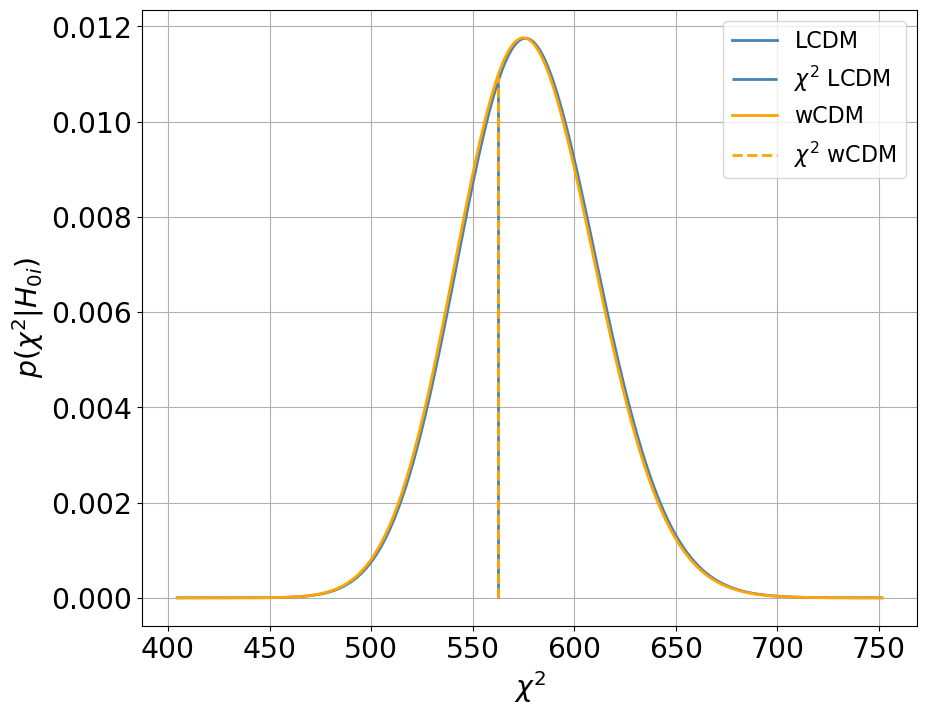

In [161]:
def compute_chi2(which_model, data=data):
    z_obs, y_obs, sigma_y = data

    theta_mle = theta_mle_dict[which_model]

    summand = ((y_obs - model_prediction(z_obs, theta_mle, which_model)) / sigma_y) ** 2
    return np.sum(summand)


def compute_dof(which_model, data=data):
    nparams = 2
    if which_model == 'LCDM':
        nparams = 2
    elif which_model == 'wCDM':
        nparams = 3
    return data[0].shape[0] - nparams


def pdf_chi2(which_model):
    chi2 = compute_chi2(which_model)
    dof = compute_dof(which_model)
    return stats.chi2(dof).pdf(chi2)


print('chi2')
for model in ['LCDM', 'wCDM']:
    print(f'{model} model, chi2:\t {compute_chi2(model):.2f}')
    print(f'{model} model, dof:\t {dof_dict[model]:.2f}')
    print(f'{model} model, chi2/dof:\t {compute_chi2(model) / dof_dict[model]:.3f}')
    print(f'{model} model, pdf(chi2):\t {pdf_chi2(model):.3f}')
    print('')


dof = compute_dof('LCDM')
x = np.linspace(dof - 0.3 * dof, dof + 0.3 * dof, 1000)

plt.figure(figsize=(10, 8))
model = 'LCDM'
plt.plot(x, stats.chi2(compute_dof(model)).pdf(x), label=model, color='steelblue')
plt.vlines(
    compute_chi2(model),
    0,
    np.max(stats.chi2(compute_dof(model)).pdf(compute_chi2(model))),
    color='steelblue',
    label=r'$\chi^2$ %s' % model,
)
model = 'wCDM'
plt.plot(x, stats.chi2(compute_dof(model)).pdf(x), label=model, color='orange')
plt.vlines(
    compute_chi2(model),
    0,
    np.max(stats.chi2(compute_dof(model)).pdf(compute_chi2(model))),
    color='orange',
    linestyles='dashed',
    label=r'$\chi^2$ %s' % model,
)
plt.legend(prop={'size': 16})
plt.xlabel(r'$\chi^2$')
plt.ylabel(r'$p(\chi^2|H_{0i})$')
plt.grid()


# Perform hypothesis test to check whether LCDM or wCDM can be rejected

We perform a p-value test to check the compatibility of the null hypothesis ("the model is true") with the observed data. The p-value is defined as (for a one-sided right-tailed test):
$$p = P(\chi^2 \geq  \chi^2_{obs} | H_0) = \int^{\infty}_{\chi^2_{obs}} \text {pdf}(\chi^2|H_0)\text d \chi^2$$
It is the probability of measuring a more extreme value than the one observed, *if the null hypothesis $H_0$ is true* (which is not the probability that $H_0$ is true!). If this probability is very low, then there is very little chanche that, if H_0 is true, will yeld an equally or more extreme result (read: the data is very unlikely under $H_0$) \
Being $\alpha$ the established threshold for rejecting $H_0$ (usually 0.05, or 5%):
* if $p > \alpha$, $H_0$ is not rejected at $(1-\alpha)$ "confidence"
* if $p < \alpha$, $H_0$ is rejected at $(1-\alpha)$ "confidence"
If the measured p-value is smaller than the established threshold (usually 0.05, or 5%), $H_0$ is rejected at $(1-\alpha)$ "confidence"

In [162]:
integrand = lambda chi2, dof: stats.chi2(dof).pdf(chi2)


def p_value_test(which_model, alpha, direction):
    dof = compute_dof(which_model)
    chi2_measured = compute_chi2(which_model)
    if direction == 'left':
        p_value = quad(integrand, -np.inf, chi2_measured, args=(dof,))[0]
    elif direction == 'right':
        p_value = quad(integrand, chi2_measured, np.inf, args=(dof,))[0]
    return p_value


model = 'LCDM'
p_val_threshold = 0.05
p_value = p_value_test(model, p_val_threshold, 'right')
if p_value > p_val_threshold:
    print(
        f'p-value = {p_value:.3f} > {p_val_threshold} - the null hypothesis (the {model} model) cannot be rejected'
    )
model = 'wCDM'
p_value = p_value_test(model, p_val_threshold, 'right')
if p_value > p_val_threshold:
    print(
        f'p-value = {p_value:.3f} > {p_val_threshold} - the null hypothesis (the {model} model) cannot be rejected'
    )


p-value = 0.673 > 0.05 - the null hypothesis (the LCDM model) cannot be rejected
p-value = 0.662 > 0.05 - the null hypothesis (the wCDM model) cannot be rejected


# Perform $\chi^2$-diff test to select between competing models

A possible test to discriminate between the competing models is to check the likelihood ratio, computing $R=\dfrac{{\cal L}_{LCDM}(\text{data}|\hat{\boldsymbol{\theta}}_1)}{ {\cal L}_{wCDM}(\text{data}|\hat{\boldsymbol{\theta}}_2)}$. $\hat{\boldsymbol{\theta}}_i$ refer to the different best-fit parameters of the two models. This quantity is also a random variable following a $\chi^2$ distribution with $\nu_{LCDM}-\nu_{wCDM}$, which in this case equals to 1.

null hypothesis:	 LCDM is the true model
alternative hypothesis:	 wCDM is the true model

p-value = 0.961 > 0.05 - the null hypothesis (LCDM is the true model) cannot be rejected


<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
<>:26: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:37: SyntaxWarning: invalid escape sequence '\D'
<>:38: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_1538/610941299.py:26: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(x, pdf_chi2, 'steelblue', label='$pdf(\Delta\chi^2)$')
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_1538/610941299.py:32: SyntaxWarning: invalid escape sequence '\D'
  label='$\Delta\chi^2$ measured',
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_1538/610941299.py:37: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta\chi^2$')
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_1538/610941299.py:38: Synt

Text(0, 0.5, '$pdf(\\Delta\\chi^2)$')

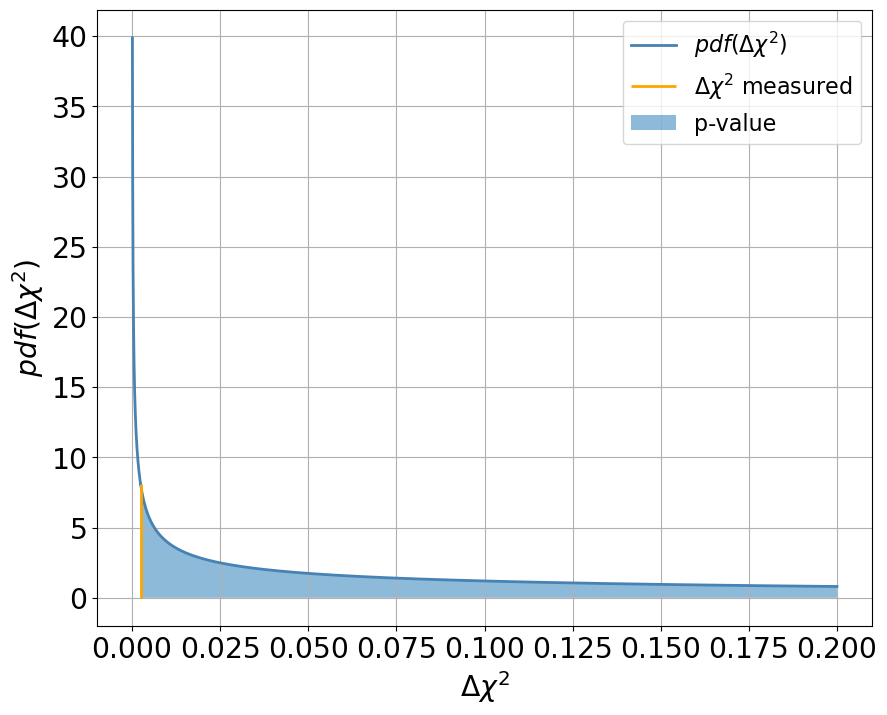

In [163]:
print('null hypothesis:\t LCDM is the true model')
print('alternative hypothesis:\t wCDM is the true model')
print('')

# compute chi2 diff and diff in dofs
chi2_diff = compute_chi2('LCDM') - compute_chi2('wCDM')
dof_diff = compute_dof('LCDM') - compute_dof('wCDM')

# compute p-value
p_value = quad(integrand, chi2_diff, np.inf, args=(dof_diff,))[0]
if p_value > p_val_threshold:
    print(
        f'p-value = {p_value:.3f} > {p_val_threshold} - the null hypothesis (LCDM is the true model) cannot be rejected'
    )

# plot distribution and p-value
plt.figure(figsize=(10, 8))

x = np.linspace(0.0001, chi2_diff, 1000)
pdf_chi2 = stats.chi2(dof_diff).pdf(x)  # 1 dof
plt.plot(x, pdf_chi2, 'steelblue')


x = np.linspace(chi2_diff, 0.2, 1000)
pdf_chi2 = stats.chi2(dof_diff).pdf(x)
plt.plot(x, pdf_chi2, 'steelblue', label='$pdf(\Delta\chi^2)$')
plt.vlines(
    chi2_diff,
    0,
    stats.chi2(dof_diff).pdf(chi2_diff),
    colors='orange',
    label='$\Delta\chi^2$ measured',
)
plt.fill_between(x, 0, pdf_chi2, alpha=0.5, label='p-value')
plt.grid()
plt.legend(prop={'size': 16})
plt.xlabel('$\Delta\chi^2$')
plt.ylabel('$pdf(\Delta\chi^2)$')


([], [])

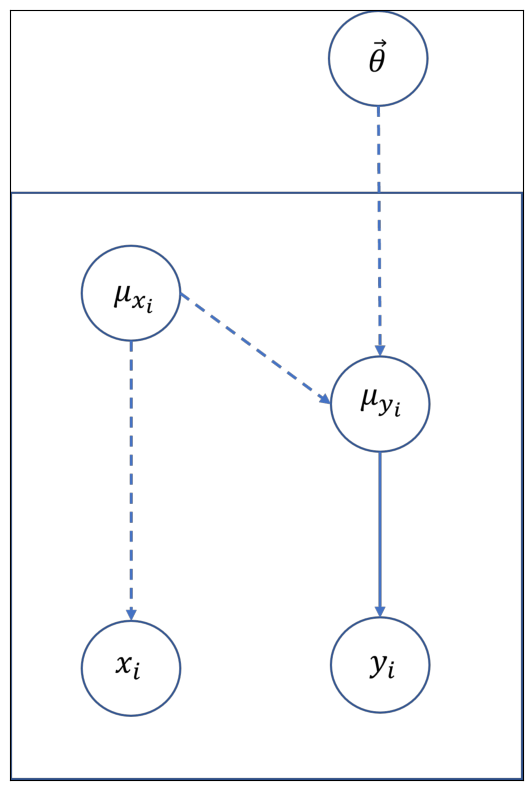

In [164]:
import matplotlib.image as img

plt.subplots(figsize=(10, 10))
# read png image file
im = img.imread(f'{root}/input/Bayesian_network.png')

plt.imshow(im)
plt.xticks([])
plt.yticks([])

# Bayesian approach: constructing and sampling the posterior
Now we turn to a Bayesian approach for parameter estimation and model selection; the posterior distribution of the parameters given the data is given by Bayes' theorem:

$$p(\boldsymbol\theta | \text {data}) = \dfrac{p(\text {data}|\boldsymbol\theta)p(\boldsymbol \theta)}   {p(\text{data})}  $$

This simple relation comes from a number of assumptions in our simplified model;calling for a moment $z_i = x_i$ and $DM_i = y_i$, we have in fact:
- deterministic relation between the measurements $x_i$ and $\mu_{xi}$ : $f(x_i|\mu_{xi}) = \delta(\mu_{xi}-x_i)$
- deterministic relation between $\mu_{yi}$ and $\mu_{xi}, \boldsymbol\theta$ : $f(\mu_{yi}|\mu_{xi}, \boldsymbol\theta) = \delta(\mu_{yi}-\mu_y(\mu_{xi}, \boldsymbol\theta))$
- probabilistic relation only between $y_i$ and $\mu_{yi}$ : $f(y_i|\mu_{yi}) = \cal N (\mu_{yi}, \sigma_{yi}) = \cal N (\mu_y(\mu_{xi}, \boldsymbol\theta), \sigma_{yi})$

In this case this allows us to write

\begin{align*}
p(\boldsymbol\theta | \text {data}) &=& f(\boldsymbol \theta|\boldsymbol x, \boldsymbol y) = \int f(\boldsymbol \theta, \boldsymbol\mu_{x}, \boldsymbol\mu_{y}|\boldsymbol x, \boldsymbol y)\text d \boldsymbol\mu_{x} \text d \boldsymbol\mu_{y}\\
&\propto& \int f(\boldsymbol \theta, \boldsymbol\mu_{x}, \boldsymbol\mu_{y},\boldsymbol x, \boldsymbol y)\text d \boldsymbol\mu_{x} \text d \boldsymbol\mu_{y}\\
&\propto& \int f(\boldsymbol x|\boldsymbol \mu_{x})f(\boldsymbol y| \boldsymbol \mu_{y})f(\boldsymbol \mu_{y}|\boldsymbol \mu_x, \boldsymbol\theta)f(\boldsymbol \mu_x) f(\boldsymbol \theta)\text d \boldsymbol\mu_{x} \text d \boldsymbol\mu_{y} \\
&\propto&  f(\boldsymbol y| \boldsymbol \mu_{y}(\boldsymbol x, \boldsymbol \theta))f(\boldsymbol\theta) = p(\text {data}|\boldsymbol\theta)p(\boldsymbol \theta)
\end{align*}

having used the Dirac deltas to perform the integrals in $\boldsymbol\mu_{x}, \boldsymbol\mu_{y}$


We choose flat and relatively broad priors distribution for the parameters' values, with ranges $[0.3,1.1],[0,1],[-2,0]$  for $(h_0, \Omega_m, w_0)$ respectively, so as to be data-dominated.

We use the $\tt {emcee}$ Python package for the sampling process, with 2000 steps and 10 independent walkers starting from the best-fit values obtained by minimizing the NLL, with a small random deviation from such position for each walker. We discard the initial 10% of the points as burn-in








In [165]:
burn_in_steps = int(Nsteps * burn_in_fraction)

trace_dict = {}
for model in models:
    fraction = 0.1
    theta_mle = theta_mle_dict[model]
    ndim = theta_mle.size
    if model == 'LCDM':
        theta_0 = np.asarray(
            [
                theta_mle
                + [
                    np.random.uniform(
                        -fraction * theta_mle[0], fraction * theta_mle[0]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[1], fraction * theta_mle[1]
                    ),
                ]
                for i in range(Nwalkers)
            ]
        )
    elif model == 'wCDM':
        theta_0 = np.asarray(
            [
                theta_mle
                + [
                    np.random.uniform(
                        -fraction * theta_mle[0], fraction * theta_mle[0]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[1], fraction * theta_mle[1]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[2], fraction * theta_mle[2]
                    ),
                ]
                for i in range(Nwalkers)
            ]
        )

    sampler = emcee.EnsembleSampler(Nwalkers, ndim, ln_posterior, args=(data, model))
    pos, prob, state = sampler.run_mcmc(theta_0, Nsteps, progress=True)

    trace_dict[model] = sampler.chain[:, burn_in_steps:, :].reshape(-1, ndim)

  0%|          | 8/2000 [00:00<01:42, 19.37it/s]

100%|██████████| 2000/2000 [02:20<00:00, 14.26it/s]


### Save chains

In [166]:
for _model in models:
    np.save(
        f'{root}/output/trace_{_model}_steps_{Nsteps}_walkers_{Nwalkers}.npy',
        trace_dict[_model],
    )

### Compute expected values, variances and probabilities

In [183]:
means_dict = {'LCDM': [], 'wCDM': []}
sigmas_dict = {'LCDM': [], 'wCDM': []}
probs_dict = {'LCDM': [], 'wCDM': []}
covs_dict = {}

for _model in models:
    print(f'\n--------------------- {_model} -------------------------------------\n')

    theta_mle = theta_mle_dict[_model]
    ndim = theta_mle.size
    trace = trace_dict[_model]

    for param_index in range(ndim):
        mean = np.mean(trace[:, param_index])
        sigma = np.std(trace[:, param_index])
        
        # the pdf is essentially the histogram of the samples in the trace, 
        # normalized to 1
        pdf, bins = np.histogram(trace[:, param_index], bins=200, density=True)
        x = 0.5 * (bins[1:] + bins[:-1])  # central value of each bin
        # compute the probability of the parameter being within 1 sigma of the mean
        mask = (x >= mean - sigma) & (x <= mean + sigma)
        prob = np.trapezoid(pdf[mask], x[mask])

        means_dict[_model].append(mean)
        sigmas_dict[_model].append(sigma)
        probs_dict[_model].append(prob)

    # compute parameter's covariance
    # each row is a variable, each column an observation
    cov = np.cov(trace.T, bias=True)
    covs_dict[_model] = cov
    
    # sanity check: diagonal of covariance should be the variances
    assert np.allclose(np.diag(cov), np.array(sigmas_dict[_model]) ** 2, atol=0, rtol=1e-5)

    for param_index in range(ndim):
        print(f'{par_names_dict[_model][param_index]}: {means_dict[_model][param_index]:.5f} +/- {sigmas_dict[_model][param_index]:.5f} at p = {probs_dict[_model][param_index]:.5f}')


--------------------- LCDM -------------------------------------

h: 0.69995 +/- 0.00336 at p = 0.66584
Om: 0.27956 +/- 0.01888 at p = 0.66825

--------------------- wCDM -------------------------------------

h: 0.70086 +/- 0.00471 at p = 0.68400
Om: 0.28490 +/- 0.06830 at p = 0.68419
w0: -1.05342 +/- 0.19356 at p = 0.67559


# Corner plot

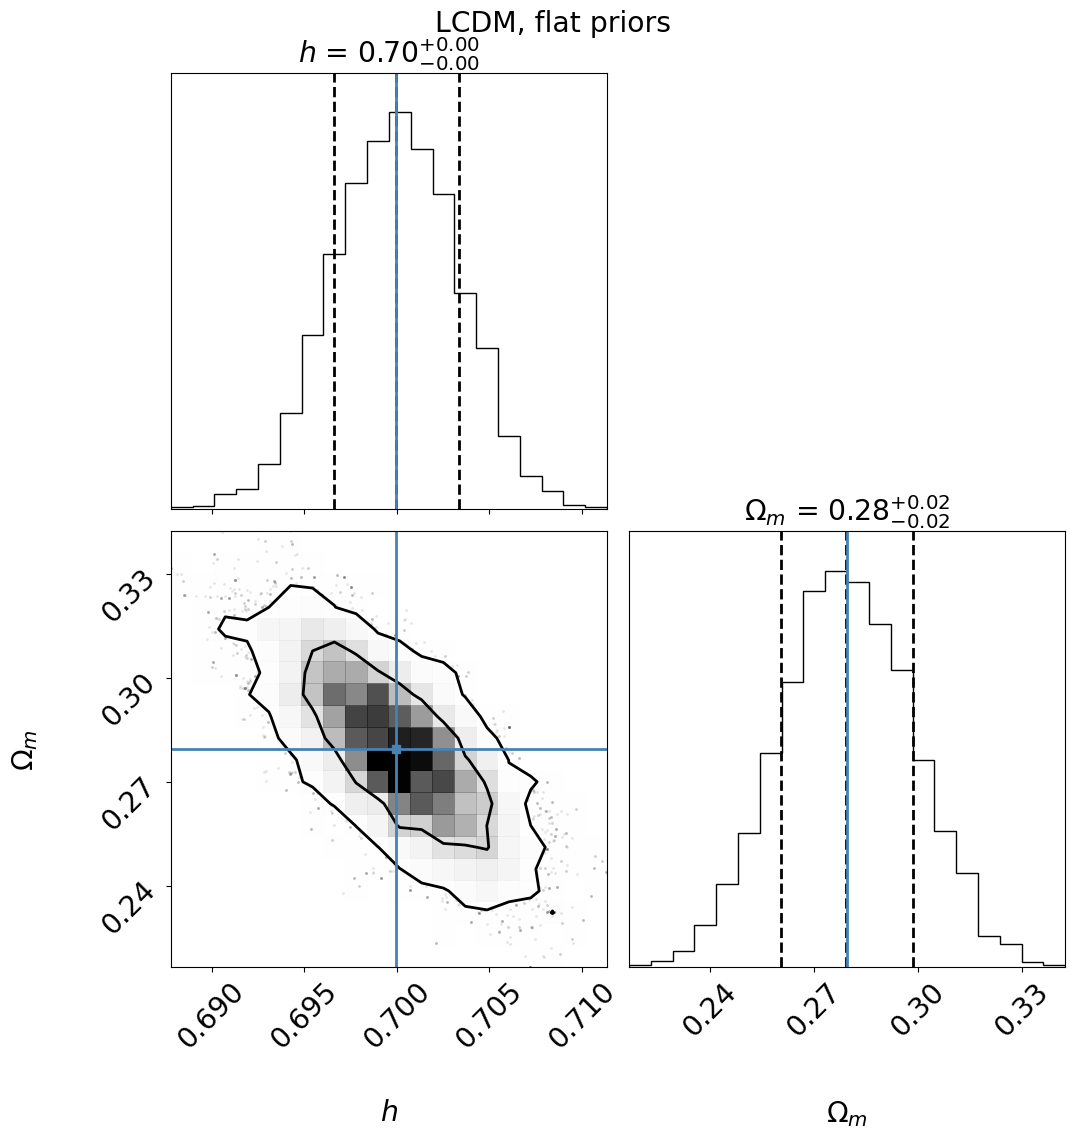

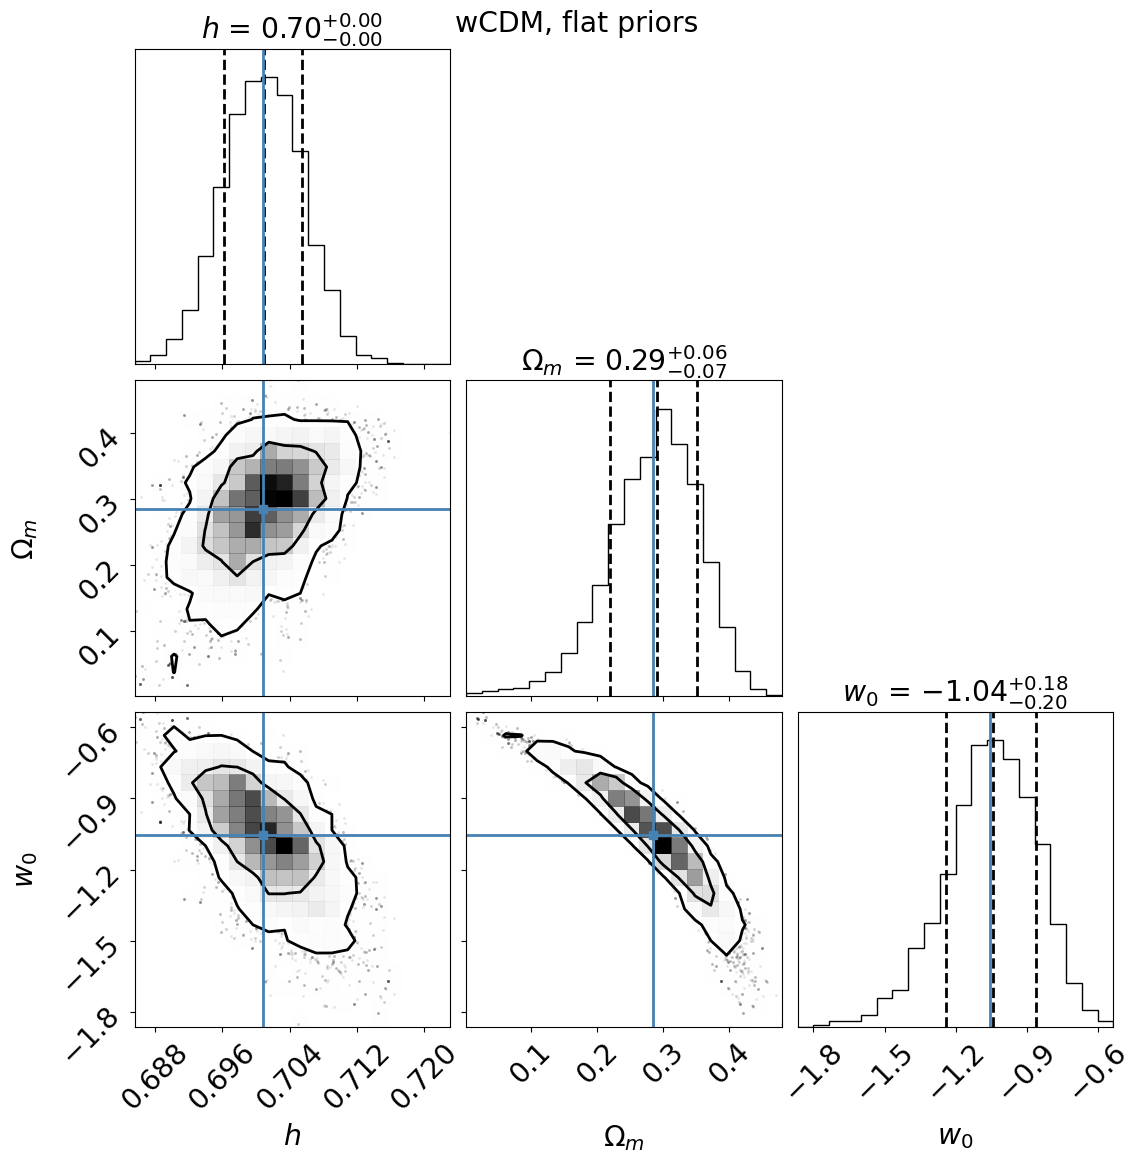

In [188]:
for _model in models:
    fig = corner.corner(
        trace_dict[_model],
        quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
        labels=par_names_tex_dict[_model],
        truths=means_dict[_model],
        plot_contours=True,
        # fill_contours=True,
        levels=(0.68, 0.95),
        show_titles=True,
    )
    fig.suptitle(f'{_model}, {prior_type} priors')
    fig.set_size_inches(12, 12)

Removed no burn in
Removed no burn in


Text(0.5, 0.98, 'LCDM vs wCDM, flat priors')

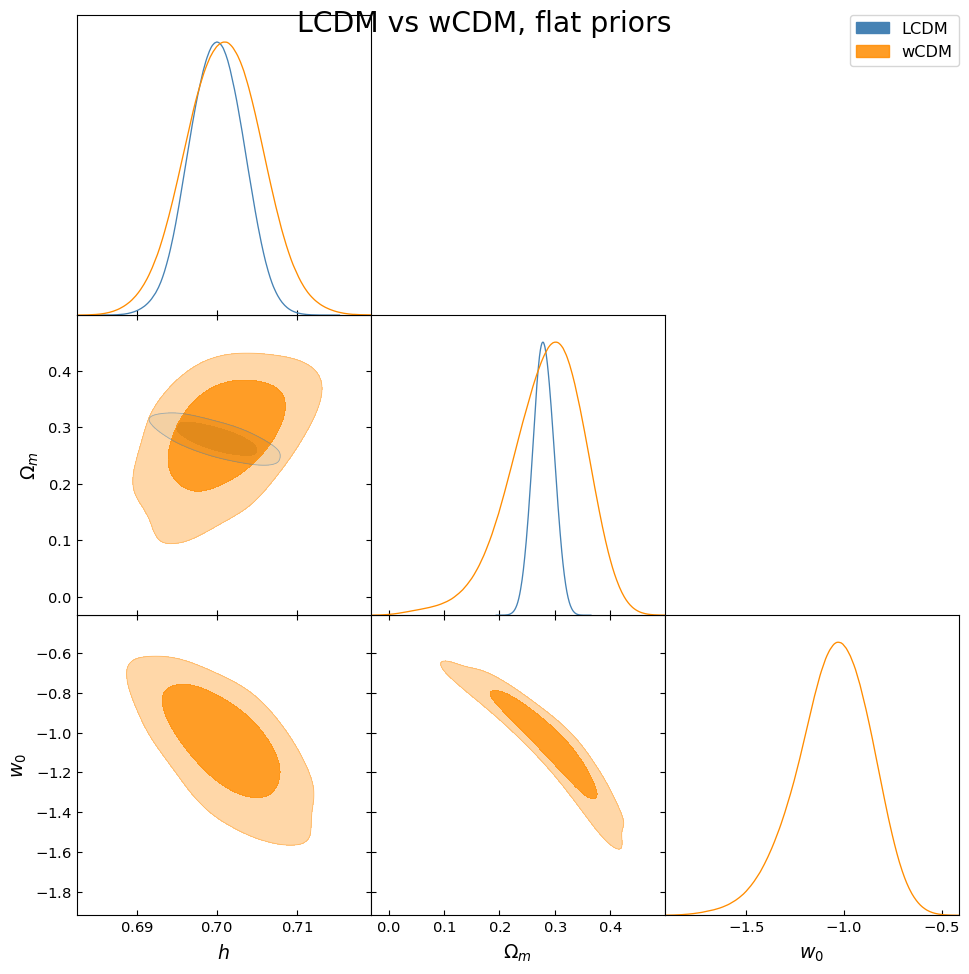

In [ ]:
from getdist import plots, MCSamples

gd_samples_dict = {}

for _model in models:
    gd_labels = [label.replace('$', '') for label in par_names_tex_dict[_model]]
    gd_names = par_names_dict[_model]

    gd_samples_dict[_model] = MCSamples(
        samples=trace_dict[_model],
        names=gd_names,
        labels=gd_labels,
        name_tag=f'{_model}_emcee',
    )
    gd_samples_dict[_model].updateSettings({'contours': [0.68, 0.95]})

# Overlay LCDM and wCDM on shared parameters only
g = plots.get_subplot_plotter(width_inch=10)
g.triangle_plot(
    [gd_samples_dict['LCDM'], gd_samples_dict['wCDM']],
    ['h', 'Om', 'w0'],
    filled=True,
    contour_colors=['steelblue', 'darkorange'],
    legend_labels=['LCDM', 'wCDM'],
)
g.fig.suptitle(f'LCDM vs wCDM, {prior_type} priors')

# Trace plot

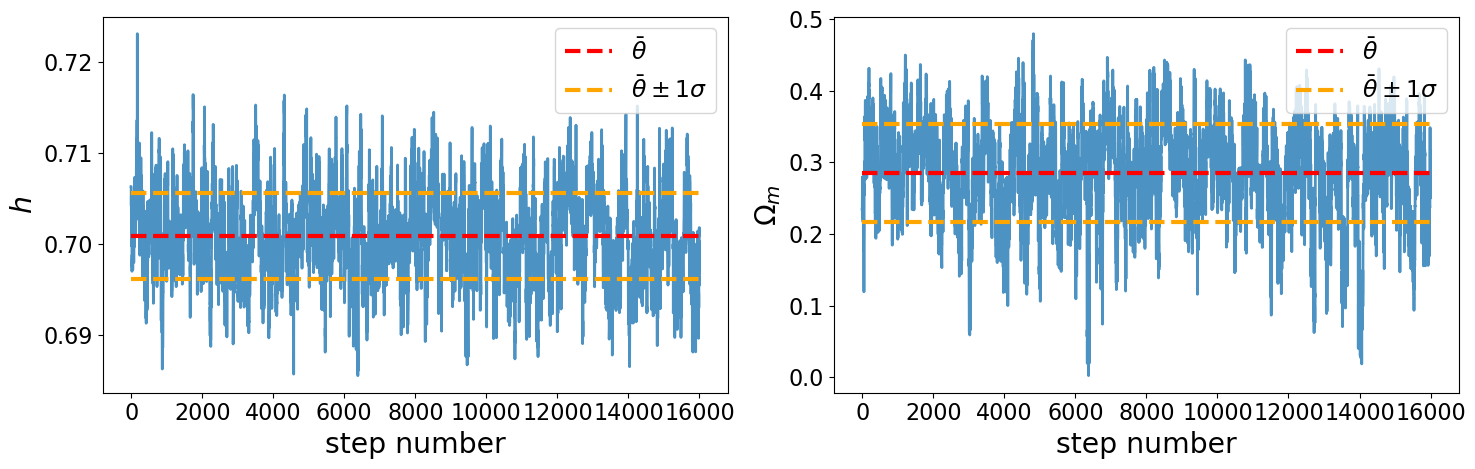

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
trace = trace_dict[model]

for i, (ax, par_name, ylabel) in enumerate(zip(axes, par_names, par_names_tex)):
    ax.plot(range(trace.shape[0]), trace[:, i], zorder=1, alpha=0.8)
    ax.set_xlabel('step number')
    ax.set_ylabel(ylabel)

    ax.hlines(
        exp_values_L[i],
        0,
        trace.shape[0],
        linestyles='dashed',
        color='red',
        zorder=2,
        label=r'$\bar{\theta}$',
        linewidth=3,
    )
    ax.hlines(
        exp_values_L[i] + sigmas_L[i],
        0,
        trace.shape[0],
        linestyles='dashed',
        color='orange',
        zorder=2,
        label=r'$\bar{\theta} \pm 1\sigma$',
        linewidth=3,
    )
    ax.hlines(
        exp_values_L[i] - sigmas_L[i],
        0,
        trace.shape[0],
        linestyles='dashed',
        color='orange',
        zorder=2,
        linewidth=3,
    )

    ax.legend(loc='upper right')
    ax.tick_params(labelsize=16)

fig.tight_layout()

# Plot best-fit curves and residuals
No appreciable difference between the two models, plot just LCDM. This simply to visually inspect the bes-fit line and to check whether the residuals show any unwanted trend.

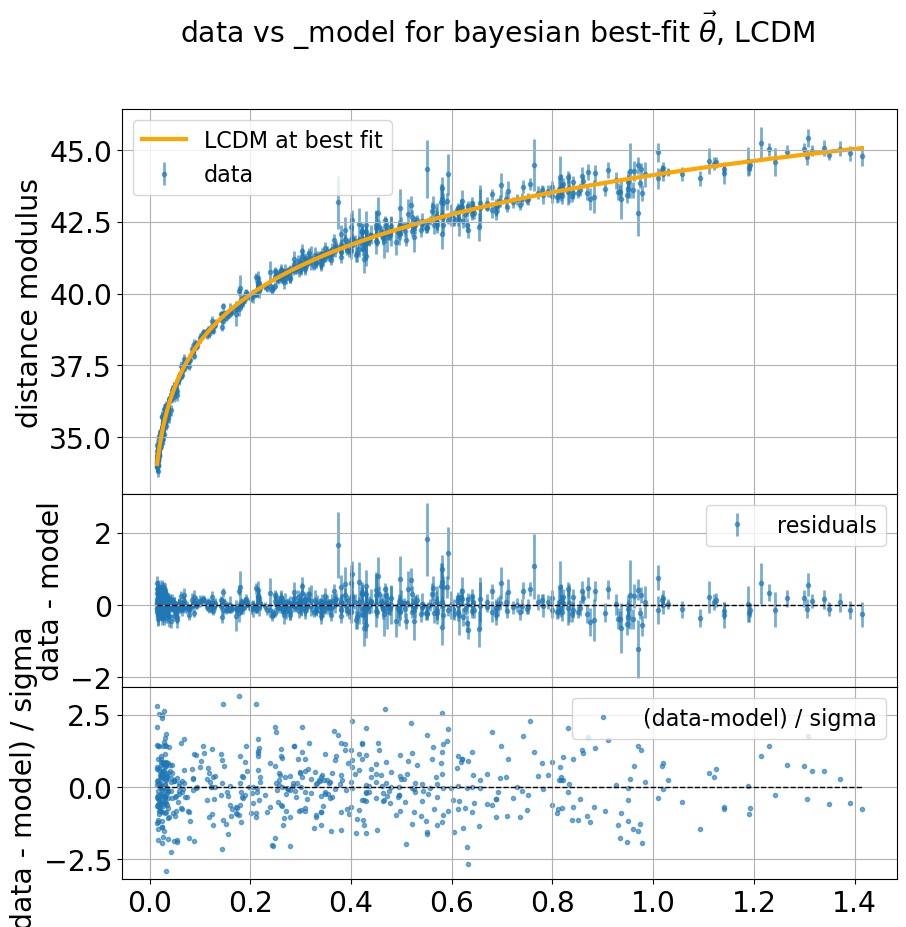

In [210]:
_model = 'LCDM'

theta_best_fit = means_dict[_model]

# sort the data
data_union = data_union[np.argsort(data_union[:, 1])]
z_obs = data_union[:, 1]
y_obs = data_union[:, 2]
sigma_y = data_union[:, 3]

fig, axs = plt.subplots(3, height_ratios=[2, 1, 1], sharex=True, gridspec_kw={'hspace': 0.0}, )
fig.suptitle('data vs _model for bayesian best-fit $\\vec{\\theta}$, %s' % _model)
fig.set_size_inches(10, 10)

axs[0].errorbar(z_obs, y_obs, yerr=sigma_y, fmt='.', alpha=0.6, label='data', zorder=1)
axs[0].plot(
    z_obs,
    model_prediction(z_obs, theta_best_fit, _model),
    label=_model + ' at best fit',
    color='orange',
    linewidth=3,
    zorder=1.5,
)
axs[1].errorbar(
    z_obs,
    y_obs - model_prediction(z_obs, theta_best_fit, _model),
    yerr=sigma_y,
    fmt='.',
    label='residuals',
    alpha=0.6,
    zorder=1,
)
axs[1].hlines(0, z_obs.min(), z_obs.max(), color='k', ls='--', zorder=2, linewidth=1)

axs[2].plot(
    z_obs,
    (y_obs-model_prediction(z_obs, theta_best_fit, _model))/sigma_y,
    ls = '',
    marker = '.',
    label='(data-model) / sigma',
    alpha=0.6,
    zorder=1,
)
axs[2].hlines(0, z_obs.min(), z_obs.max(), color='k', ls='--', zorder=2, linewidth=1)

axs[0].set_ylabel('distance modulus')
axs[1].set_ylabel('data - model')
axs[2].set_ylabel('(data - model) / sigma')
axs[1].set_xlabel(r'$z$')
axs[0].grid()
axs[1].grid()
axs[2].grid()
axs[0].legend(prop={'size': 16})
axs[1].legend(prop={'size': 16})
axs[2].legend(prop={'size': 16})

# Bayesian model selection
In order to select the best model we compute the odds ratio

$$O_{12} = \dfrac{p(M_1|\text{data})}{p(M_2|\text{data})}=\dfrac{p(\text{data}|M_1)P(M_1)}{p(\text{data}|M_2)P(M_2)}=\dfrac{\int p(\text{data}|M_1,\boldsymbol\theta_1)p(\boldsymbol\theta_1|M_1)\text{d}\boldsymbol\theta_1}{\int p(\text{data}|M_2,\boldsymbol\theta_2)p(\boldsymbol\theta_2|M_2)\text{d}\boldsymbol\theta_2}\dfrac{p(M_1)}{p(M_2)}$$

which is simply the ratio of the posterior distributions, marginalized over the parameters of the models, folded with the prior probabilities on the different models (which we consider equal to each other).


Models with more parameters will be penalized with respect to models with fewer parameters, because the larger the number of parameters the more spread the prior will have with respect to the likelihood.


Already in 3-dimensional parameter space (for model wCDM) the computation takes a very long time. We therefore implement a routine to integrate the function with a simple random sampling of the posterior over the prior domain, exploiting the relation

$$\int f (\boldsymbol x) \text d \boldsymbol x \simeq \prod_{i=1}^d (b_i-a_i)\langle f(\boldsymbol x) \rangle =  \dfrac{\prod_{i=1}^d (b_i-a_i)}{N} \sum_{i=1}^N f(\boldsymbol x_i)$$

with $N$ number of sampling points, $d$ the number of dimensions of $\boldsymbol x$, and $(a_i, b_i)$ lower and upper bounds of the different priors' domains. The $x_i$ are, in our case, drawn from a uniform pdf.

1.2738407899573954e-05
7.182778424138693e-05
0.17734652452545133
170.66666666666669
0.34705186056559845
2.460977875889861 200


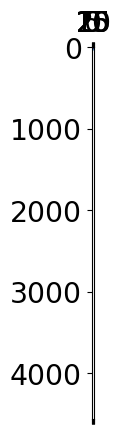

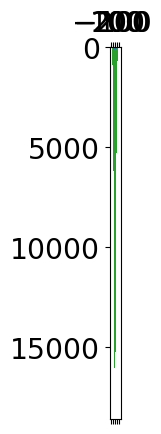

In [ ]:
"""
def mc_integrate_3D(func, ranges, n = 10000):

    low_h0, high_h0, low_Om, high_Om, low_w0, high_w0 = ranges

    h0_list = np.random.uniform(low_h0, high_h0, n)
    Om_list = np.random.uniform(low_Om, high_Om, n)
    w0_list = np.random.uniform(low_w0, high_w0, n)

    y = np.asarray([func(h0_list[i], Om_list[i], w0_list[i]) for i in range(n)])

    y_mean =  (y.sum())/len(y)
    domain = (high_h0-low_h0)*(high_Om-low_Om)*(high_w0-low_w0)

    integral = domain * y_mean
    return integral


h0_lim = (0.3, 1.1)
Om_lim = (0,1)
w0_lim = (-2,0)


start = time.time()
which_model = "LCDM"
ranges = (h0_lim, Om_lim)
integrand = lambda h, Om: np.exp(ln_posterior([h, Om], data, which_model))
Z_L = nquad(integrand, ranges) # integrate with nquad
print(f"Z_L = {Z_L[0]:.3e}, {which_model}, {time.time() - start:.1f} seconds to compute the integral")


start = time.time()
which_model = "wCDM"
ranges = np.asarray((h0_lim, Om_lim, w0_lim)).reshape(6).tolist()
integrand = lambda h, Om, w0: np.exp(ln_posterior([h, Om, w0], data, which_model))
Z_w_MC = mc_integrate_3D(integrand, ranges, n = 10000)  # integrate with MC

# ranges = (h0_lim, Om_lim, w0_lim)
# Z_w_nquad = nquad(integrand, ranges)  # integrate with nquad - very slow

Z_w = Z_w_MC
print(f"Z_w = {Z_w:.3e}, {which_model}, {time.time() - start:.1f} seconds to compute the integral")

O12 = Z_L[0]/Z_w
print(f"O12 = {O12:.3f} > 1, LCDM is the preferred model")
if (1 < O12 <= 3): print("strenght of evidence in facour of LCDM: barely worth mentioning")
elif (3 < O12 <= 10): print("substantial support for LCDM")

print('\ncomputation using scipy nquad:')
Z_w = 3.319218472708639063e+47
O12 = Z_L[0]/Z_w
print(f"O12 = {O12:.3f} > 1, LCDM is the preferred model")
if (1 < O12 <= 3): print("strenght of evidence in facour of LCDM: barely worth mentioning")
elif (3 < O12 <= 10): print("substantial support for LCDM")
"""

################### INTEGRATE THE POSTERIOR SAMPLED FROM MCMC ("trace")
nbins = 20

p1_index = 0
p2_index = 1
p3_index = 2

trace = trace_L
fxy, p1_bin_edges, p2_bin_edges = np.histogram2d(
    trace[:, p1_index], trace[:, p2_index], bins=18
)
plt.matshow(fxy)

delta_p1 = p1_bin_edges[1:] - p1_bin_edges[:-1]
delta_p2 = p2_bin_edges[1:] - p2_bin_edges[:-1]
integral_L = np.sum(delta_p1 * delta_p2 * fxy) / np.sum(fxy)
print(integral_L)

trace = trace_w
fxyz, edges = np.histogramdd(
    (trace[:, p1_index], trace[:, p2_index], trace[:, p3_index]), bins=7
)
edges = np.asarray((edges))
delta_p1 = edges[0, 1:] - edges[0, :-1]
delta_p2 = edges[1, 1:] - edges[1, :-1]
delta_p3 = edges[2, 1:] - edges[2, :-1]

integral_w = np.sum(delta_p1 * delta_p2 * delta_p3 * fxyz) / np.sum(fxyz)
print(integral_w)

print(integral_L / integral_w)


prova = lambda x, y: x**2 + y**2
ranges = ((0, 4), (0, 4))
integral = nquad(prova, ranges)
print(integral[0])

marginal_x = lambda x: (x**2) / 4 + 64 / 3
marginal_y = lambda y: (y**2) / 4 + 64 / 3

N = 10000
x_rand = np.random.uniform(-1, 5, N)
y_rand = np.random.uniform(-1, 5, N)
sampled_marginal_x = marginal_x(x_rand)
sampled_marginal_y = marginal_y(y_rand)
sampled_function = prova(x_rand, y_rand)

t = np.linspace(-1, 5, 1000)
plt.plot(t, marginal_x(t))
plt.hist(sampled_marginal_x)

fxy, p1_bin_edges, p2_bin_edges = np.histogram2d(
    trace[:, p1_index], trace[:, p2_index], nbins
)
plt.matshow(fxy)

plt.plot(np.sort(x_rand), marginal_x(np.sort(x_rand)))
np.sort(x_rand)
marginal_x(np.sort(x_rand))

fx, p1_bin_edges, _ = plt.hist(sampled_marginal_x)
delta_p1 = p1_bin_edges[1:] - p1_bin_edges[:-1]
integral = np.sum(delta_p1 * fx) / np.sum(fxy)
print(integral)

N = 900000
nbins = 200
x = np.random.normal(0, 50, N)
fx, bins, _ = plt.hist(x, bins=nbins)
area = sum(np.diff(bins) * fx) / sum(fx)
print(area, nbins)

# Gaussian priors
We adopt narrow gaussian prior distribution to check how the result change with more restrictive prior knowledge

In [ ]:
"""# Gaussian priors

prior_type = 'gauss'
trace_dict = {}

for which_model in models:
    fraction = 0.1
    theta_mle = theta_mle_dict[which_model]
    if which_model == 'LCDM':
        ndim = theta_mle.size
        p0 = np.asarray(
            [
                theta_mle
                + [
                    np.random.uniform(
                        -fraction * theta_mle[0], fraction * theta_mle[0]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[1], fraction * theta_mle[1]
                    ),
                ]
                for i in range(Nwalkers)
            ]
        )
    elif which_model == 'wCDM':
        ndim = theta_mle.size
        p0 = np.asarray(
            [
                theta_mle
                + [
                    np.random.uniform(
                        -fraction * theta_mle[0], fraction * theta_mle[0]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[1], fraction * theta_mle[1]
                    ),
                    np.random.uniform(
                        -fraction * theta_mle[2], fraction * theta_mle[2]
                    ),
                ]
                for i in range(Nwalkers)
            ]
        )

    sampler = emcee.EnsembleSampler(
        Nwalkers, ndim, ln_posterior, args=(data, which_model)
    )
    pos, prob, state = sampler.run_mcmc(p0, Nsteps, progress=True)

    trace_dict[which_model] = sampler.chain[:, burn_in_steps:, :].reshape(-1, ndim)
"""

<>:51: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\O'
<>:51: SyntaxWarning: invalid escape sequence '\O'
<>:55: SyntaxWarning: invalid escape sequence '\O'
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_1538/2073728275.py:51: SyntaxWarning: invalid escape sequence '\O'
  labels = ['$h_0$', '$\Omega_m$']
/var/folders/dp/8cyfcrf94f7c57dqdtt0gx4w0000gn/T/ipykernel_1538/2073728275.py:55: SyntaxWarning: invalid escape sequence '\O'
  labels = ['$h_0$', '$\Omega_m$', '$w_0$']
100%|██████████| 2000/2000 [01:46<00:00, 18.72it/s]


NameError: name 'burn_in_steps' is not defined

#Compute expected values, variances and probabilities

In [ ]:


for model in models:
    theta_mle = theta_mle_dict[model]
    ndim = theta_mle.size
    if model == 'LCDM':
        trace = trace_L
    elif model == 'wCDM':
        trace = trace_w

    exp_values = []
    sigmas = []
    probs = []

    print(f'\n--------------------- {model} -------------------------------------\n')
    for param_index in range(ndim):  # 0 for h, 1 for Om, 2 for Ode
        fx_obs, bins = np.histogram(trace[:, param_index], bins=500, density=False)
        x_obs = (bins[1:] + bins[:-1]) / 2

        mean = expectation(x_obs, fx_obs)
        Var = variance(x_obs, fx_obs)
        sigma = np.sqrt(Var)
        prob = get_prob(x_obs, fx_obs, mean - sigma, mean + sigma)

        exp_values.append(mean)
        sigmas.append(sigma)
        probs.append(prob)

    # compute parameter's covariance
    cov = np.cov(
        trace.T, bias=True
    )  # each row is a variable, each column an observation

    print(f'{par_names[0]}: {exp_values[0]:.3f} +/- {sigmas[0]:.3f} at P = {prob:.2f}')
    print(f'{par_names[1]}: {exp_values[1]:.3f} +/- {sigmas[1]:.3f} at P = {prob:.2f}')
    if model == 'wCDM':
        print(
            f'{par_names[2]}: {exp_values[2]:.2f} +/- {sigmas[2]:.2f} at P = {prob:.2f}'
        )

    corr = np.zeros(cov.shape)
    for i in range(cov.shape[0]):
        for j in range(cov.shape[0]):
            corr[i, j] = cov[i, j] / (sigmas[i] * sigmas[j])

    plt.matshow(corr)
    plt.title(model)
    plt.colorbar()

    if model == 'LCDM':
        exp_values_L = exp_values
        sigmas_L = sigmas
        probs_L = probs
        cov_L = cov
        print('\nGaussian priors:')
        print(f'h: mu = {exp_values_L[0]:.3f}; sigma = 0.0036')
        print(f'Om: mu = {exp_values_L[1]:.3f}; sigma = 0.0047')

    elif model == 'wCDM':
        exp_values_w = exp_values
        sigmas_w = sigmas
        probs_w = probs
        cov_w = cov
        print('\nGaussian priors:')
        print(f'h: mu = {exp_values_w[0]:.3f}; sigma = 0.0073')
        print(f'Om: mu = {exp_values_w[1]:.3f}; sigma = 0.0066')
        print(f'w_0: mu = {exp_values_w[2]:.3f}; sigma = 0.027')

    print("\nparameters' covariance matrix:")
    print(cov)
    print("\nparameters' correlation matrix:")
    print(corr)
    print('')

# Corner plot

In [ ]:
fig = corner.corner(
    trace_dict['LCDM'],
    quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
    labels=par_names_tex,
    truths=exp_values_L,
    plot_contours=True,
    # fill_contours=True,
    # levels=(0.68, 0.95),
    show_titles=True,
)
fig.suptitle(f'{model}, Nwalkers = {Nwalkers}, Nsteps = {Nsteps}, {prior_type} priors')
fig.set_size_inches(10, 10)

In [ ]:
fig = corner.corner(
    trace_dict['wCDM'],
    quantiles=[0.16, 0.5, 0.84],  # meaning: x* where p(x<x*) = 16, 50, 84%
    labels=par_names_tex,
    truths=exp_values_w,
    plot_contours=True,
    # fill_contours=True,
    # levels=(0.68, 0.95),
    show_titles=True,
)
fig.suptitle(f'{model}, Nwalkers = {Nwalkers}, Nsteps = {Nsteps}, {prior_type} priors')
fig.set_size_inches(10, 10)

# Nested sampling with nautilus (flat priors)


## 1) Define flat priors and likelihood for nautilus
We use the same flat priors adopted above with `emcee`: $h_0\in[0.3,1.1]$, $\Omega_m\in[0,1]$, and (for wCDM) $w_0\in[-2,0]$.


In [211]:
from nautilus import Prior, Sampler


def build_nautilus_prior(which_model):
    prior = Prior()
    for param_name in par_names_dict[which_model]:
        prior.add_parameter(
            param_name, dist=(prior_ranges[param_name][0], prior_ranges[param_name][1])
        )
    return prior


def ln_likelihood_nautilus(params, which_model):
    if which_model == 'LCDM':
        theta = [params['h'], params['Om']]
    elif which_model == 'wCDM':
        theta = [params['h'], params['Om'], params['w0']]
    else:
        raise ValueError(f'Unknown model: {which_model}')

    return ln_likelihood(theta, data, which_model)

## 2) Sample LCDM with nautilus


In [ ]:
prior_LCDM = build_nautilus_prior('LCDM')

sampler_nautilus_LCDM = Sampler(
    prior_LCDM,
    ln_likelihood_nautilus,
    likelihood_kwargs={'which_model': 'LCDM'},
    n_live=n_live,
    seed=seed,
)
start = time.perf_counter()
_ = sampler_nautilus_LCDM.run(verbose=True)
print(f'nautilus LCDM took {time.perf_counter() - start:.1f} seconds to run')

points_LCDM, log_w_LCDM, log_l_LCDM = sampler_nautilus_LCDM.posterior(
    return_as_dict=True
)
logZ_LCDM = sampler_nautilus_LCDM.log_z

print(f'LCDM: logZ = {logZ_LCDM:.3f}, n_eff = {sampler_nautilus_LCDM.n_eff:.1f}')

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    


## 3) Sample wCDM with nautilus


In [ ]:
prior_wCDM = build_nautilus_prior('wCDM')

sampler_nautilus_wCDM = Sampler(
    prior_wCDM,
    ln_likelihood_nautilus,
    likelihood_kwargs={'which_model': 'wCDM'},
    n_live=n_live,
    seed=seed + 1,
)
start = time.perf_counter()
_ = sampler_nautilus_wCDM.run(verbose=True)
print(f'nautilus LCDM took {time.perf_counter() - start:.1f} seconds to run')

points_wCDM, log_w_wCDM, log_l_wCDM = sampler_nautilus_wCDM.posterior(
    return_as_dict=True
)
logZ_wCDM = sampler_nautilus_wCDM.log_z

print(f'wCDM: logZ = {logZ_wCDM:.3f}, n_eff = {sampler_nautilus_wCDM.n_eff:.1f}')

KeyError: 'w0'

## 4) Bayesian model comparison from evidences


In [ ]:
logB_LCDM_wCDM = logZ_LCDM - logZ_wCDM

if logB_LCDM_wCDM >= 0:
    preferred_model = 'LCDM'
    logB = logB_LCDM_wCDM
else:
    preferred_model = 'wCDM'
    logB = -logB_LCDM_wCDM

print(f'logZ_LCDM = {logZ_LCDM:.3f}')
print(f'logZ_wCDM = {logZ_wCDM:.3f}')
print(f'log Bayes factor (LCDM / wCDM) = {logB_LCDM_wCDM:.3f}')
print(f'Preferred model: {preferred_model}')

if logB < 1:
    strength = 'inconclusive'
elif logB < 2.5:
    strength = 'weak'
elif logB < 5:
    strength = 'moderate'
else:
    strength = 'strong'

print(f'Evidence strength: {strength}')


# Fisher-matrix approximation vs nautilus


## 1) Compute numerical derivatives of $\mu(z, \theta)$


In [ ]:
def numerical_jacobian(theta, which_model, eps_frac=1e-4):
    param_names = par_names_dict[which_model]
    theta = np.array(theta, dtype=float)
    n_params = len(theta)
    jac = np.zeros((z_obs.size, n_params))

    mu0 = model(z_obs, theta, which_model)

    for j, pname in enumerate(param_names):
        low, high = prior_ranges[pname]
        step = eps_frac * (high - low)

        theta_plus = theta.copy()
        theta_minus = theta.copy()

        if theta[j] - step < low:
            theta_plus[j] += step
            mu_plus = model(z_obs, theta_plus, which_model)
            jac[:, j] = (mu_plus - mu0) / step
        elif theta[j] + step > high:
            theta_minus[j] -= step
            mu_minus = model(z_obs, theta_minus, which_model)
            jac[:, j] = (mu0 - mu_minus) / step
        else:
            theta_plus[j] += step
            theta_minus[j] -= step
            mu_plus = model(z_obs, theta_plus, which_model)
            mu_minus = model(z_obs, theta_minus, which_model)
            jac[:, j] = (mu_plus - mu_minus) / (2.0 * step)

    return jac


## 2) Compute Fisher matrix


In [ ]:
def logw_to_prob(log_w):
    w = np.exp(log_w - np.max(log_w))
    return w / np.sum(w)


def nautilus_weighted_mean(points_dict, log_w, param_names):
    p = logw_to_prob(log_w)
    mean = np.array([np.sum(points_dict[name] * p) for name in param_names])
    return mean, p


def fisher_matrix(theta, which_model):
    J = numerical_jacobian(theta, which_model)
    inv_var = 1.0 / (sigma_y**2)
    return J.T @ (inv_var[:, None] * J)


nautilus_points = {'LCDM': points_LCDM, 'wCDM': points_wCDM}
nautilus_logw = {'LCDM': log_w_LCDM, 'wCDM': log_w_wCDM}

fisher_results = {}

for which_model in ['LCDM', 'wCDM']:
    param_names = par_names_dict[which_model]
    theta_fid, p = nautilus_weighted_mean(
        nautilus_points[which_model], nautilus_logw[which_model], param_names
    )

    F = fisher_matrix(theta_fid, which_model)
    condF = np.linalg.cond(F)
    if np.isfinite(condF) and condF < 1e12:
        C = np.linalg.inv(F)
        inversion = 'inv'
    else:
        C = np.linalg.pinv(F)
        inversion = 'pinv'

    fisher_results[which_model] = {
        'param_names': param_names,
        'theta_fid': theta_fid,
        'weights': p,
        'F': F,
        'C': C,
    }

    print(f'\n{which_model}')
    print('theta_fid =', theta_fid)
    print('cond(F) =', condF, f'({inversion})')
    print('Fisher matrix =')
    print(F)
    print('Fisher sigmas =', np.sqrt(np.diag(C)))


NameError: name 'points_wCDM' is not defined

## 3) Build getdist samples for nautilus and Fisher approximation


In [ ]:
try:
    from getdist import MCSamples, plots
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'getdist is not installed. Install it with: pip install getdist'
    ) from exc

label_map = {'h0': 'h_0', 'Om': r'\Omega_m', 'w0': 'w_0'}

rng = np.random.default_rng(12345)
n_nautilus_draws = 100000
n_fisher_draws = 100000

getdist_nautilus = {}
getdist_fisher = {}

for which_model in ['LCDM', 'wCDM']:
    param_names = fisher_results[which_model]['param_names']
    labels = [label_map[p] for p in param_names]

    X_naut = np.column_stack([nautilus_points[which_model][p] for p in param_names])
    w = fisher_results[which_model]['weights']
    idx = rng.choice(np.arange(X_naut.shape[0]), size=n_nautilus_draws, p=w)
    X_naut_eq = X_naut[idx]

    theta_fid = fisher_results[which_model]['theta_fid']
    C = fisher_results[which_model]['C']
    X_fisher = rng.multivariate_normal(theta_fid, C, size=n_fisher_draws)

    getdist_nautilus[which_model] = MCSamples(
        samples=X_naut_eq,
        names=param_names,
        labels=labels,
        name_tag=f'{which_model}_nautilus',
    )
    getdist_fisher[which_model] = MCSamples(
        samples=X_fisher,
        names=param_names,
        labels=labels,
        name_tag=f'{which_model}_fisher',
    )


## 4) Overlay FM results against nautilus results (getdist)


In [ ]:
for which_model in ['LCDM', 'wCDM']:
    param_names = fisher_results[which_model]['param_names']

    g = plots.get_subplot_plotter(width_inch=8)
    g.triangle_plot(
        [getdist_nautilus[which_model], getdist_fisher[which_model]],
        param_names,
        filled=True,
        contour_colors=['steelblue', 'orange'],
        legend_labels=['nautilus', 'Fisher matrix'],
    )
    g.fig.suptitle(f'{which_model}: nautilus vs Fisher matrix', y=1.02)
